In [1]:
!pip install pandas numpy scikit-learn seaborn matplotlib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv("data.csv")

print("Shape:", df.shape)
df.head()

Shape: (171, 1204)


,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22,Class
0,0.0908,0,0.0075,0.0173,0,0.0,-0.0436,0.0409,0.0,0.1368,...,0.0000,0.0000,0.1780,1.5488,0.0088,0,0.0,-0.0868,0.00,NonToxic
1,0.0213,0,0.1144,-0.0410,0,0.0,0.1231,-0.0316,0.0,0.1318,...,8.8660,19.3525,0.1739,1.3718,0.0048,2,0.0,-0.0810,0.25,NonToxic
2,0.0018,0,-0.0156,-0.0765,2,0.0,-0.1138,-0.1791,0.0,0.0615,...,5.2267,27.8796,0.1688,1.4395,0.0116,2,0.0,-0.1004,0.00,NonToxic
3,-0.0251,0,-0.0064,-0.0894,3,0.0,-0.0747,-0.1151,0.0,0.0361,...,7.7896,24.7336,0.1702,1.4654,0.0133,2,0.0,-0.1010,0.00,NonToxic
4,0.0135,0,0.0424,-0.0353,0,0.0,-0.0638,0.0307,0.0,0.0306,...,12.3240,19.7486,0.1789,1.4495,0.0120,2,0.0,-0.1071,0.00,NonToxic


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum().sum()

0

In [6]:
df = df.dropna()

In [7]:
df['Class'].value_counts()

Class
NonToxic    115
Toxic        56
Name: count, dtype: int64

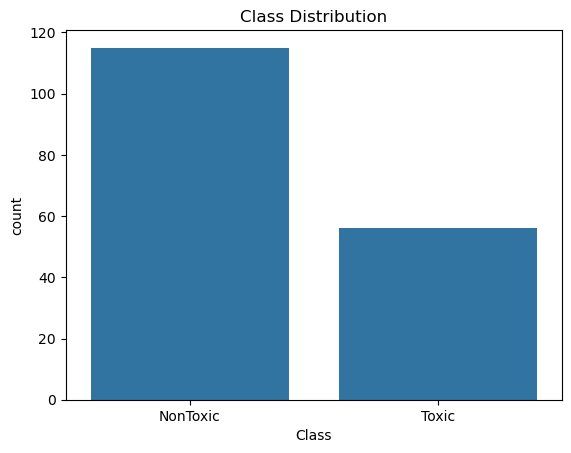

In [8]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

In [9]:
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])

df['Class'].value_counts()

Class
0    115
1     56
Name: count, dtype: int64

In [10]:
X = df.drop(columns=['Class'])
y = df['Class']

In [11]:
var_selector = VarianceThreshold(threshold=0.01)

X_var = var_selector.fit_transform(X)

print("Original features:", X.shape[1])
print("After variance filter:", X_var.shape[1])

Original features: 1203
After variance filter: 994


In [12]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_var, y)

selector = SelectFromModel(rf, prefit=True)

X_selected = selector.transform(X_var)

print("Features after RF selection:", X_selected.shape[1])

Features after RF selection: 410


In [13]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_selected,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.6        0.61764706 0.64705882 0.58823529 0.61764706]
Mean Accuracy: 0.6141176470588235


In [14]:
model.fit(X_selected, y)

RandomForestClassifier(n_estimators=300, random_state=42)

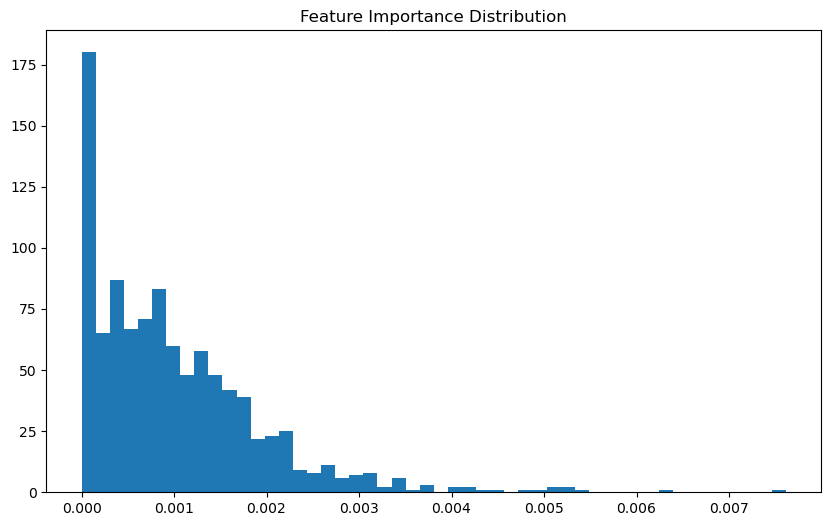

In [15]:
importances = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.hist(importances, bins=50)
plt.title("Feature Importance Distribution")
plt.show()

              precision    recall  f1-score   support

           0       0.66      0.86      0.75       115
           1       0.27      0.11      0.15        56

    accuracy                           0.61       171
   macro avg       0.47      0.48      0.45       171
weighted avg       0.54      0.61      0.55       171



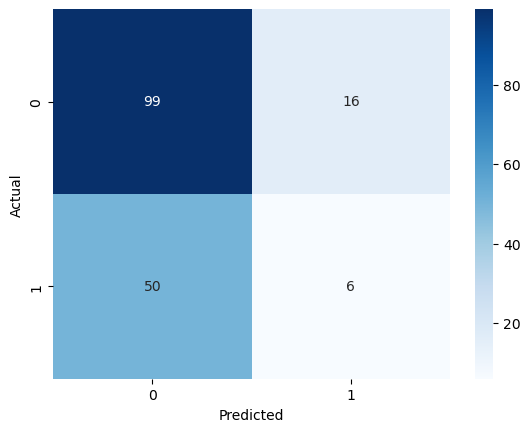

In [16]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(model, X_selected, y, cv=cv)

print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [35]:
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [37]:
grid_search.fit(X_selected, y)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [42]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [41]:
print("Best Accuracy:", grid_search.best_score_)

Best Accuracy: 0.6373109243697479


In [43]:
best_model = grid_search.best_estimator_

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X_selected,
    y,
    cv=5,
    scoring='accuracy'
)

print("Tuned CV Scores:", scores)
print("Tuned Mean Accuracy:", scores.mean())

Tuned CV Scores: [0.65714286 0.58823529 0.55882353 0.67647059 0.70588235]
Tuned Mean Accuracy: 0.6373109243697479


              precision    recall  f1-score   support

           0       0.69      0.85      0.76       115
           1       0.39      0.20      0.26        56

    accuracy                           0.64       171
   macro avg       0.54      0.52      0.51       171
weighted avg       0.59      0.64      0.60       171



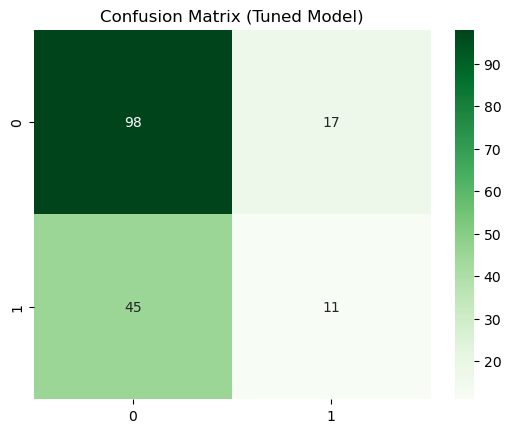

In [50]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(best_model, X_selected, y, cv=5)

print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix (Tuned Model)")
plt.show()